In [ ]:
pip install pandas numpy matplotlib scikit-learn yfinance nltk

In [ ]:
import yfinance as yf
import pandas as pd

stock = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")
stock = stock[['Close']]
stock.reset_index(inplace=True)

print(stock.head())

/tmp/ipykernel_8131/19464195.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("TCS.NS", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price        Date        Close
Ticker                  TCS.NS
0      2020-01-01  1866.113892
1      2020-01-02  1857.548096
2      2020-01-03  1894.566772
3      2020-01-06  1894.394653
4      2020-01-07  1899.043701


In [ ]:
companies = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "HINDUNILVR.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "ITC.NS",
    "LT.NS"
]

In [ ]:
import yfinance as yf
import pandas as pd

all_data = []

for company in companies:
    df = yf.download(company, start="2020-01-01", end="2024-01-01")
    df = df[['Close']]
    df.reset_index(inplace=True)

    df['Company'] = company
    all_data.append(df)

# Combine all
stock_data = pd.concat(all_data)

print(stock_data.head())

/tmp/ipykernel_8131/3256670919.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/3256670919.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/3256670919.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/3256670919.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price        Date       Close      Company  Close                      \
Ticker            RELIANCE.NS              TCS.NS INFY.NS HDFCBANK.NS   
0      2020-01-01  675.324219  RELIANCE.NS    NaN     NaN         NaN   
1      2020-01-02  686.821167  RELIANCE.NS    NaN     NaN         NaN   
2      2020-01-03  687.648804  RELIANCE.NS    NaN     NaN         NaN   
3      2020-01-06  671.700684  RELIANCE.NS    NaN     NaN         NaN   
4      2020-01-07  682.034607  RELIANCE.NS    NaN     NaN         NaN   

Price                                                                 
Ticker ICICIBANK.NS HINDUNILVR.NS SBIN.NS BHARTIARTL.NS ITC.NS LT.NS  
0               NaN           NaN     NaN           NaN    NaN   NaN  
1               NaN           NaN     NaN           NaN    NaN   NaN  
2               NaN           NaN     NaN           NaN    NaN   NaN  
3               NaN           NaN     NaN           NaN    NaN   NaN  
4               NaN           NaN     NaN           NaN    NaN

In [ ]:
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

# Sort
stock_data = stock_data.sort_values(['Company', 'Date'])

print(stock_data.tail())

Price        Date       Close Company        Close                      \
Ticker            RELIANCE.NS               TCS.NS INFY.NS HDFCBANK.NS   
987    2023-12-22         NaN  TCS.NS  3561.377441     NaN         NaN   
988    2023-12-26         NaN  TCS.NS  3534.880859     NaN         NaN   
989    2023-12-27         NaN  TCS.NS  3549.456055     NaN         NaN   
990    2023-12-28         NaN  TCS.NS  3538.932129     NaN         NaN   
991    2023-12-29         NaN  TCS.NS  3532.878174     NaN         NaN   

Price                                                                 
Ticker ICICIBANK.NS HINDUNILVR.NS SBIN.NS BHARTIARTL.NS ITC.NS LT.NS  
987             NaN           NaN     NaN           NaN    NaN   NaN  
988             NaN           NaN     NaN           NaN    NaN   NaN  
989             NaN           NaN     NaN           NaN    NaN   NaN  
990             NaN           NaN     NaN           NaN    NaN   NaN  
991             NaN           NaN     NaN           NaN

In [ ]:
import numpy as np

# Fake sentiment (replace later with real NLP output)
np.random.seed(42)
stock_data['Sentiment'] = np.random.uniform(-1, 1, len(stock_data))

In [ ]:
print(stock_data.isna().sum())

Price      Ticker       
Date                           0
Close      RELIANCE.NS      8928
Company                        0
Close      TCS.NS           8928
           INFY.NS          8928
           HDFCBANK.NS      8928
           ICICIBANK.NS     8928
           HINDUNILVR.NS    8928
           SBIN.NS          8928
           BHARTIARTL.NS    8928
           ITC.NS           8928
           LT.NS            8928
Sentiment                      0
dtype: int64


In [ ]:
stock_data = stock_data.dropna()

In [ ]:
print("Before cleaning:", stock_data.shape)
print(stock_data.head())

Before cleaning: (0, 13)
Empty DataFrame
Columns: [(Date, ), (Close, RELIANCE.NS), (Company, ), (Close, TCS.NS), (Close, INFY.NS), (Close, HDFCBANK.NS), (Close, ICICIBANK.NS), (Close, HINDUNILVR.NS), (Close, SBIN.NS), (Close, BHARTIARTL.NS), (Close, ITC.NS), (Close, LT.NS), (Sentiment, )]
Index: []


In [ ]:
print(stock_data.columns)

MultiIndex([(     'Date',              ''),
            (    'Close',   'RELIANCE.NS'),
            (  'Company',              ''),
            (    'Close',        'TCS.NS'),
            (    'Close',       'INFY.NS'),
            (    'Close',   'HDFCBANK.NS'),
            (    'Close',  'ICICIBANK.NS'),
            (    'Close', 'HINDUNILVR.NS'),
            (    'Close',       'SBIN.NS'),
            (    'Close', 'BHARTIARTL.NS'),
            (    'Close',        'ITC.NS'),
            (    'Close',         'LT.NS'),
            ('Sentiment',              '')],
           names=['Price', 'Ticker'])


In [ ]:
stock_data.columns = ['_'.join(col).strip() for col in stock_data.columns.values]

In [ ]:
print(stock_data.columns)

Index(['Date_', 'Close_RELIANCE.NS', 'Company_', 'Close_TCS.NS',
       'Close_INFY.NS', 'Close_HDFCBANK.NS', 'Close_ICICIBANK.NS',
       'Close_HINDUNILVR.NS', 'Close_SBIN.NS', 'Close_BHARTIARTL.NS',
       'Close_ITC.NS', 'Close_LT.NS', 'Sentiment_'],
      dtype='object')


In [ ]:
stock_data = stock_data.melt(
    id_vars=['Date_', 'Company_', 'Sentiment_'],
    var_name='Stock',
    value_name='Close'
)

In [ ]:
stock_data = stock_data.rename(columns={
    'Date_': 'Date',
    'Company_': 'Company',
    'Sentiment_': 'Sentiment'
})

In [ ]:
stock_data['Company'] = stock_data['Stock'].str.replace('Close_', '')
stock_data.drop(columns=['Stock'], inplace=True)

In [ ]:
stock_data = stock_data.dropna(subset=['Close'])
stock_data['Sentiment'] = stock_data['Sentiment'].fillna(0)

In [ ]:
all_data = []

for company in companies:
    df = yf.download(company, start="2020-01-01", end="2024-01-01")
    df = df.reset_index()
    df['Company'] = company
    df = df[['Date', 'Close', 'Company']]
    all_data.append(df)

stock_data = pd.concat(all_data)

/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
all_data = []

for company in companies:
    df = yf.download(company, start="2020-01-01", end="2024-01-01")
    df = df.reset_index()
    df['Company'] = company
    df = df[['Date', 'Close', 'Company']]
    all_data.append(df)

stock_data = pd.concat(all_data)

/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/1798733895.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
import yfinance as yf
import pandas as pd

companies = [
    "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
    "HINDUNILVR.NS","SBIN.NS","BHARTIARTL.NS","ITC.NS","LT.NS"
]

all_data = []

for company in companies:
    df = yf.download(company, start="2020-01-01", end="2024-01-01")
    df = df.reset_index()

    df['Company'] = company
    df = df[['Date', 'Close', 'Company']]

    all_data.append(df)

stock_data = pd.concat(all_data)

print("After download:", stock_data.shape)

/tmp/ipykernel_8131/2736986053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/2736986053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/2736986053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8131/2736986053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(company, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 comple

After download: (9920, 12)


In [ ]:
import numpy as np

stock_data['Sentiment'] = np.random.uniform(-1, 1, len(stock_data))

In [ ]:
stock_data = stock_data.dropna(subset=['Close'])
stock_data['Sentiment'] = stock_data['Sentiment'].fillna(0)

print("After cleaning:", stock_data.shape)

After cleaning: (9920, 13)


In [ ]:
print(stock_data.columns.tolist())

[('Date', ''), ('Close', 'RELIANCE.NS'), ('Company', ''), ('Close', 'TCS.NS'), ('Close', 'INFY.NS'), ('Close', 'HDFCBANK.NS'), ('Close', 'ICICIBANK.NS'), ('Close', 'HINDUNILVR.NS'), ('Close', 'SBIN.NS'), ('Close', 'BHARTIARTL.NS'), ('Close', 'ITC.NS'), ('Close', 'LT.NS'), ('Sentiment', '')]


In [ ]:
stock_data.columns = [col[0] + '_' + col[1] if col[1] != '' else col[0] for col in stock_data.columns]

In [ ]:
print(stock_data.columns)

Index(['Date', 'Close_RELIANCE.NS', 'Company', 'Close_TCS.NS', 'Close_INFY.NS',
       'Close_HDFCBANK.NS', 'Close_ICICIBANK.NS', 'Close_HINDUNILVR.NS',
       'Close_SBIN.NS', 'Close_BHARTIARTL.NS', 'Close_ITC.NS', 'Close_LT.NS',
       'Sentiment'],
      dtype='object')


In [ ]:
stock_data = stock_data.melt(
    id_vars=['Date', 'Sentiment'],
    var_name='Company',
    value_name='Close'
)

In [ ]:
stock_data['Company'] = stock_data['Company'].str.replace('Close_', '')

In [ ]:
stock_data = stock_data.dropna(subset=['Close'])
stock_data['Sentiment'] = stock_data['Sentiment'].fillna(0)

In [ ]:
print(stock_data.head())
print(stock_data.shape)

        Date  Sentiment      Company       Close
0 2020-01-01  -0.338522  RELIANCE.NS  675.324219
1 2020-01-02   0.127103  RELIANCE.NS  686.821167
2 2020-01-03   0.704748  RELIANCE.NS  687.648804
3 2020-01-06  -0.227626  RELIANCE.NS  671.700684
4 2020-01-07  -0.877640  RELIANCE.NS  682.034607
(19840, 4)


In [ ]:
import pandas as pd

stock_data['Close'] = pd.to_numeric(stock_data['Close'], errors='coerce')

In [ ]:
stock_data = stock_data.dropna(subset=['Close'])

In [ ]:
print(stock_data['Close'].dtype)

float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = stock_data[['Sentiment']]
y = stock_data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [ ]:
stock_data['Prev_Close'] = stock_data.groupby('Company')['Close'].shift(1)
stock_data = stock_data.dropna()

In [ ]:
X = stock_data[['Sentiment', 'Prev_Close']]

In [ ]:
# Previous day price (very important feature)
stock_data['Prev_Close'] = stock_data.groupby('Company')['Close'].shift(1)

# Daily return
stock_data['Return'] = stock_data.groupby('Company')['Close'].pct_change()

# Remove NaN created by shift
stock_data = stock_data.dropna()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = stock_data[['Sentiment', 'Prev_Close', 'Return']]
y = stock_data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained")

✅ Model trained


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 191.63791560641567
R2 Score: 0.9997355675175051


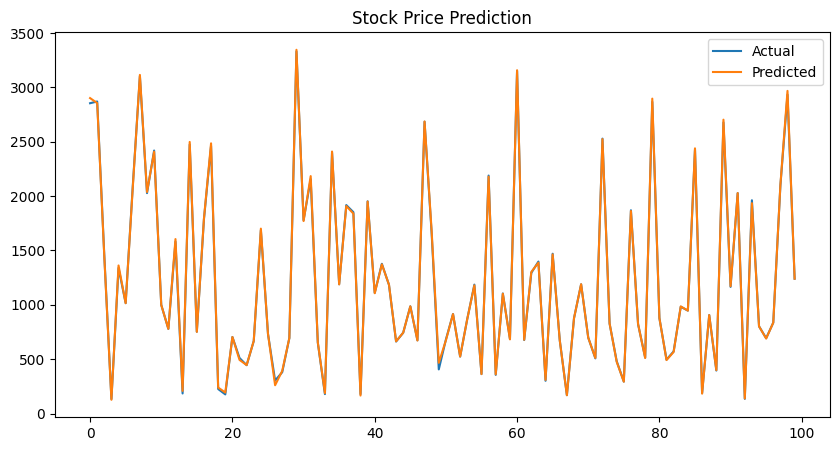

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

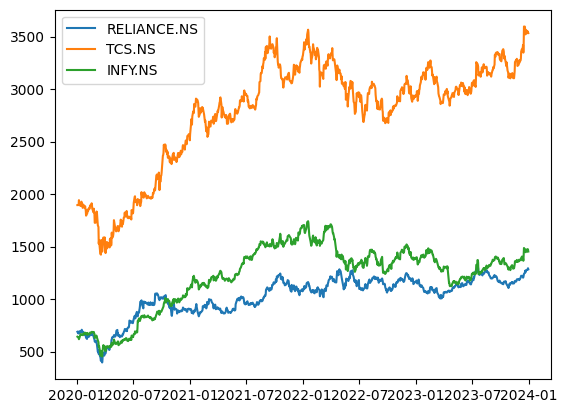

In [ ]:
for company in stock_data['Company'].unique()[:3]:
    df = stock_data[stock_data['Company'] == company]
    plt.plot(df['Date'], df['Close'], label=company)

plt.legend()
plt.show()